## Paso 1: Definicio de Librerias

In [4]:
# Manejo de datos
import pandas as pd
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# División de datos
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import os
from pathlib import Path

In [16]:
import importlib
import utils

importlib.reload(utils)

<module 'utils' from 'c:\\Users\\juanc\\Documents\\GitHub\\IA\\HousingPricesAI\\utils.py'>

## Dataset info

- El congunto datos
  - train.csv: tiene todos los datos
  - test.csv: solo test, sin `SalePrice`
- Datos 1461 para cada congunto

---

Descripcion:

- Columnas: representan una variable, tiene variaciones entre sus opciones
  - numerico, permite calculos matematicos
    - discretas, valores enteros
    - continua, enteros y decimales
  - categorica, son categorias o etiqueras
- Filas: Representan un congunto de datos asociados a una casa

---

Cantidades:

- entrenamiento: 1461 datos
  - entrenar: 1 168,8 | 80%
  - Validacion: 292,2 | 20%
- test: 1461 datos

---

variables: 

- cantidad de variables usadas: 20/81
  - 12 numericas
  - 8 categoricas
- variable objectivo: `SalePrice`

## Paso 2: cargar el dataset, con seleccion de variavles

In [6]:
# Cargar el dataset
base_path = Path.cwd()

train_path = base_path / "output" / "train.csv"
test_path = base_path / "output" / "test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

# Variables seleccionadas y refinadas (ver justificación en variables_relevantes_modelo.md)
numeric_features = [
    "OverallQual", "GrLivArea", "TotalBsmtSF", "1stFlrSF", 
    "GarageCars", "LotArea", "YearBuilt", "YearRemodAdd", 
    "FullBath", "TotRmsAbvGrd", "Fireplaces", "OverallCond"
]

categorical_features = [
    "Neighborhood", "ExterQual", "KitchenQual", "BsmtQual", 
    "Foundation", "MSZoning", "SaleCondition", "CentralAir"
]

features = numeric_features + categorical_features

# * Seflección de variables para entrenamiento
X = train[features]
X_test = test[features]

# variable objectivo
y = train["SalePrice"]

## Generar reporte de variables usadas

In [ ]:
# reporte = "# Variables obtenidas\n\n"

# for col in df.columns:
#     valores = df[col].dropna().unique()
#     tipo = df[col].dtype
#     reporte += f"## {col}\n\n"
#     if tipo in ["float64", "int64"]:
#         if len(valores) > 15:
#             reporte += "[Datos numéricos variables]\n\n"
#         else:
#             valores_ordenados = sorted(valores)
#             reporte += ", ".join(str(v) for v in valores_ordenados) + "\n\n"
#     else:
#         valores_ordenados = sorted(
#             valores, key=lambda x: (str(x).lower() if isinstance(x, str) else x)
#         )
#         reporte += ", ".join(str(v) for v in valores_ordenados) + "\n\n"

# with open(base_path / "output" / "reporte_variables_usadas.md", "w", encoding="utf-8") as f:
#     f.write(reporte)


## Procesamiento de variables

convierte variables no numericas a numericas

In [7]:
# Conversión de variables categóricas a numéricas
from sklearn.preprocessing import LabelEncoder

# Copia para no modificar los originales
def encode_features(df):
    df = df.copy()
    # Label Encoding para variable binaria
    le = LabelEncoder()
    df['CentralAir'] = le.fit_transform(df['CentralAir'])  # N=0, Y=1
    
    # One-Hot Encoding para el resto de variables categóricas
    cat_vars = [
        'Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual',
        'Foundation', 'MSZoning', 'SaleCondition'
    ]
    df = pd.get_dummies(df, columns=cat_vars, drop_first=True)
    return df

X = encode_features(X)
X_test = encode_features(X_test)


In [8]:
df = pd.concat([X, X_test], ignore_index=True)

## Separacion de dataset

In [ ]:
# División en entrenamiento y validación (80/20)
X, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -todos los datos
df = pd.concat([X, X], ignore_index=True)


print(f"Dataset cargado. Variables seleccionadas: {len(features)}")
print(f"Numéricas: {len(numeric_features)}, Categóricas: {len(categorical_features)}")

Dataset cargado. Variables seleccionadas: 20
Numéricas: 12, Categóricas: 8


## Columnas resultantes

In [11]:
X.columns

Index(['OverallQual', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageCars',
       'LotArea', 'YearBuilt', 'YearRemodAdd', 'FullBath', 'TotRmsAbvGrd',
       'Fireplaces', 'OverallCond', 'CentralAir', 'Neighborhood_Blueste',
       'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr',
       'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards',
       'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV',
       'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer',
       'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr',
       'Neighborhood_Timber', 'Neighborhood_Veenker', 'ExterQual_Fa',
       'ExterQual_Gd', 'ExterQual_TA', 'KitchenQual_Fa', 'KitchenQual_Gd',
       'KitchenQual_TA', 'BsmtQual_Fa', 'BsmtQual_Gd', 'BsmtQual_TA',
       'Foundat

## Verificacion de variables

Varaiables debe ser de tipo numerico las variables

In [ ]:
X.info()

## Aprendizaje del agente

T: Tarea  
E: Experiencia  
P: Error de prediccion  

## Diagrama de correlacion de datos

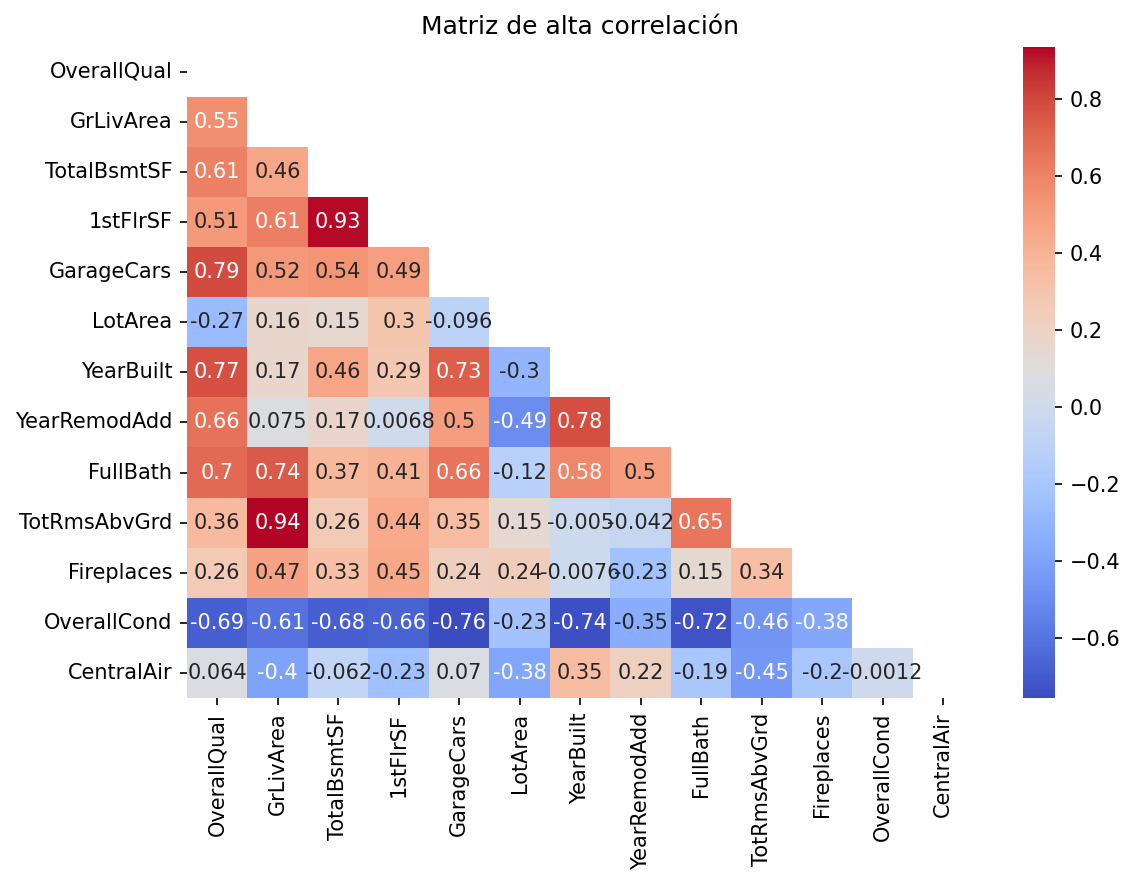

In [9]:
utils.diagrama_alta_correlacion(df)

## Resumen de variables descartables

In [ ]:
cat_cols, num_cols, cat_but_car,  num_but_cat = utils.grab_col_names(df)
utils.columnas_baja_correlacion(df, num_cols)

KeyError: 60